# XLEAP Detector

This notebook detects XLEAP using undulator taper, and quantifies the taper in MeV/fs, and reports which undulators are lasing.

## Theory

**Reference:** [K.-J. Kim, Z. Huang, and R. Lindberg, “Undulator Radiation,” in *Synchrotron Radiation and Free-Electron Lasers: Principles of Coherent X-Ray Generation*, Cambridge: Cambridge University Press, 2017, pp. 43–45](https://www.cambridge.org/core/books/synchrotron-radiation-and-freeelectron-lasers/F90638BB364B5A3EF9A78978CE15B1A5)

In an undulator with magnetic field strength $B_0$ and wavenumber $k_u$, the electrons encounter a magnetic field in $\hat y$

$$
\vec{B}_u = B_0 \sin(k_u z) \hat y
$$

that produces a force in $\hat x$:

$$
\begin{align*}
\dot {\vec p} = \partial_t (\gamma mc \vec \beta)&= -e (\xcancel{\vec E} + \vec v \times \vec B) \\
&= -e(\beta c \hat z) \times B_0 \sin(k_u z) \hat y \\
&= +e\beta c B_0 \sin(k_u z) \hat x \\
\end{align*}
$$
Neglecting energy losses from steering radiation, we take $\dot \gamma = 0$ and integrate (taking $\beta_x = 0$ at $t=0$ from before the undulator) to find $\beta_x$:
$$
\begin{align*}
\dot \beta_x &= \frac{e \beta c B_0}{\gamma m c} \sin(k_u z) = \frac{e \beta B_0}{\gamma m} \sin(k_u \beta c t) \tag{$\beta_z \approx \beta \lesssim 1$} \\
\beta_x &= \left. \frac{e \beta B_0}{\gamma m k_u \beta c} \cos(k_u \beta c t)\right \vert_0^t = \frac{e B_0}{\gamma k_u m c} \cos(k_u \beta c t) - 0 = \frac{1}{\gamma}{\frac{e B_0}{k_u m c}}\cos(k_u z)  \\ 
\beta_x &= \frac{K}{\gamma} \cos(k_u z) \; \llap{\boxed{\phantom{\beta_x = \frac{K}{\gamma} \cos(k_u z)}}} \tag{$K \coloneqq {e B_0}/{k_u m c}$}

\end{align*}
$$

Again neglecting energy losses from steering radiation, we say that energy $\gamma mc^2$ and therefore total velocity $\beta$ is conserved from before the undulator, but once inside the undulator, the velocity is split between $x$ and $z$ components:

$$
\begin{align*}
{\vec \beta}^2 &= \beta_z^2 + \beta_x^2 \\
\beta_z^2 &= \vec \beta^2 - \beta_x^2 = \left(1 - \frac {1}{\gamma^2} \right) - \beta_x^2 \\
\beta_z &= \sqrt{1-\frac{1}{\gamma^2}-\beta_x^2} \\ 
&\approx 1- \frac{1}{2\gamma^2} - \frac{K^2}{2\gamma^2}\cos^2(k_u z) \tag{$\sqrt{1-\varepsilon}\approx 1-\varepsilon/2$} \\
\left\langle \beta_z \right\rangle &= 1- \frac{1}{2\gamma^2} - \frac{K^2}{2\gamma^2}\left\langle\cos^2({k_u z})\right\rangle = 1- \frac{1}{2\gamma^2} - \frac{K^2}{4\gamma^2} \\
\left\langle \beta_z \right\rangle &= 1- \left(\frac{1+K^2/2}{2\gamma^2}\right) \; \llap{\boxed{\phantom{\left\langle \beta_z \right\rangle = 1- \left(\frac{1+K^2/2}{2\gamma^2}\right)}}} 
\end{align*}
$$
Therefore, the radiation emitted by the electrons is faster than the electrons themselves by $\Delta \beta \coloneqq 1-\left\langle \beta_z \right\rangle = (1+K^2/2)/2\gamma^2$. 

The electrons now experience fields due to both the undulator magnets and their own radiation. To achieve resonance, these contributions must be in phase, so the radiation must slip ahead of the electrons by one radiation wavelength $\lambda_r$ per undulator period $\lambda_u$. Light traverses an undulator period in time $T = \lambda_u/c$, during which time the electrons fall behind by a distance $\Delta \beta c T = \lambda_u(1+K^2/2)/2\gamma^2$, called the **slippage length**. Therefore we set the radiation wavelength equal to one slippage length:
$$
\boxed{\lambda_r = \frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right)}
$$

Meanwhile, space charge forces create an energy spread within the current spike by pushing head electrons forward and tail electrons backward, so the radiation slips ahead from lower-energy to higher-energy slices of electrons: $\gamma \to \gamma + \Delta \gamma$. Due to the taper, $K$ also increases downstream: $K \to K + \Delta K$. To maintain resonance, we now need
$$
\lambda_r = \frac{\lambda_u}{2(\gamma + \Delta \gamma)^2}\left(1+\frac{(K + \Delta K)^2}{2}\right)
$$

Therefore, given a $\Delta K$ between two undulators, we can find the corresponding $\Delta \gamma$ needed to maintain resonance:
$$
\begin{align*}
\lambda_r = \frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right) &= \frac{\lambda_u}{2(\gamma+\Delta \gamma)^2}\left(1+\frac{(K+\Delta K)^2}{2}\right) \\
\implies \Delta \gamma &= \gamma\left(\sqrt{1+\frac{(K+\Delta K/2)\Delta K}{1+K^2/2}}-1\right) \; \llap{\boxed{\phantom{\Delta \gamma = \gamma\left(\sqrt{1+\frac{(K+\Delta K/2)\Delta K}{1+K^2/2}}-1\right)}}} \approx \gamma\left(\frac{K\Delta K + \Delta K^2/2}{K^2+2}\right) 
\end{align*}
$$

Finally, we define *undulator taper* as change in resonant energy $\gamma$ per slippage length $\lambda_r$. Since we find $\Delta K$ between undulators and we get $N_u = L_u/\lambda_u$ periods per undulator ($L_u = 3.4 \text{ m}$), we divide $\Delta \gamma$ by the total slippage in one undulator $\Delta s \coloneqq N_u \lambda_r$. However, we write the slippage length in units of time, $N_u \lambda_r/c$, so that we can write the result in MeV/fs.
$$
\mathrm{taper} \coloneqq \frac{\Delta \gamma}{\Delta s} = \frac{\Delta \gamma}{N_u \lambda_r/c} = \frac{\Delta \gamma \lambda_u c}{L_u} \left[\frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right)\right]^{-1} = \frac{2 \gamma^2 \Delta \gamma c}{L_u(1+K^2/2)}
$$

Surprisingly, $\lambda_u$ cancels, so we can get the taper from the list of $K$ values (which also gives $\Delta K \to \Delta \gamma$), the beam energy $\gamma$, and the length of an undulator $L_u = 3.4\text{ m}$. 

## Implementation

We do a "coarse sweep" between `start` and `end` times, taking snapshots at intervals of `coarse_delta`.
We are interested in three things:
1. Whether XLEAP is happening, indicated by the presence of at least one lasing group of tapered undulators;
2. Which undulators are lasing, as a boolean array (or number of undulators, if we sum);
3. The undulator taper as energy gain per slippage length in MeV/fs, calculated by:
    
    a) taking the median of the sorted list of $\Delta K$ within the lasing group, 
    
    b) converting to $\Delta \gamma$ using the first $K$ value of the first lasing undulator group, and
    
    c) dividing by the total slippage in a single undulator in units of time: $\Delta s = N_u \lambda_r/c$


In [1]:
import meme
import os, re, csv
import numpy as np
from datetime import timedelta, datetime as dt
from pathlib import Path

start = dt(2026, 6, 1, 0, 0)
end = dt.now()
coarse_delta = timedelta(hours=4)
snapshot_delta = timedelta(seconds=3)

## Data collection

We take the length of an undulator $L_u$ as 3.4 m, ignoring the spaces between undulators since negligible slippage occurs without the magnetic field bleeding $\beta_z$ into $\beta_x$.

We get $\gamma$ from the beam dump PV `BEND:DMPS:400:BACT`. This reports the strength of the beam dump magnet not in teslas, but as the beam momentum it is tuned to deflect. This momentum $p$ is given in units of **GeV/c**. We solve for $\gamma$ via $E = \gamma mc^2 = \sqrt{p^2c^2 + m^2c^4} \implies \gamma = \sqrt{(pc/mc^2)^2+1}$. However, since $pc \gg mc^2$, we have roughly $\gamma = pc/mc^2$, so we can basically read off $\gamma$ by dividing `BEND:DMPS:400:BACT` in GeV by $mc^2 = 0.511\text{ MeV}$.

Finally, we take a snapshot of the series of undulator $K$ values. We take $K$ as the first $K$ in the most upstream "hockey stick" region, that is, a group of at least 4 undulators whose $K$'s are increasing by at least $4\rho$ per undulator. These are discovered by binary erosion, explained in the code below. 



In [2]:
import csv
from pathlib import Path

def _fetch_archiver_snapshot(pv_names, from_time, to_time):
    if isinstance(pv_names, str):
        pv_names = [pv_names]
    payload = meme.archive.get(pv_names, from_time=from_time, to_time=to_time)
    if len(pv_names) == 1:
        pv = pv_names[0]
        return {pv: (dt.fromtimestamp(payload['secondsPastEpoch'][-1]), payload['values'][-1])}
    else:
        return {d['pvName']: (dt.fromtimestamp(d['value']['value']['secondsPastEpoch'][-1]), d['value']['value']['values'][-1]) for d in payload}


SNAPSHOT_CACHE_FIELDS = ['nominal_time', 'pv', 'timestamp', 'value']


def _read_snapshot_cache(cache_path):
    cache_path = Path(cache_path)
    if not cache_path.exists():
        return {}

    with cache_path.open(newline='') as f:
        reader = csv.DictReader(f)
        if reader.fieldnames != SNAPSHOT_CACHE_FIELDS:
            return {}

        cache = {}
        for row in reader:
            try:
                nominal_time = dt.fromisoformat(row['nominal_time'])
                timestamp = dt.fromisoformat(row['timestamp'])
                value = float(row['value'])
            except (KeyError, TypeError, ValueError):
                continue
            cache.setdefault(nominal_time, {})[row['pv']] = (timestamp, value)
        return cache


def _append_snapshot_cache(cache_path, nominal_time, snapshot):
    cache_path = Path(cache_path)
    rewrite = True
    if cache_path.exists():
        with cache_path.open(newline='') as f:
            rewrite = csv.DictReader(f).fieldnames != SNAPSHOT_CACHE_FIELDS

    mode = 'w' if rewrite else 'a'
    with cache_path.open(mode, newline='') as f:
        writer = csv.DictWriter(f, fieldnames=SNAPSHOT_CACHE_FIELDS)
        if rewrite:
            writer.writeheader()
        for pv, (timestamp, value) in snapshot.items():
            writer.writerow(
                {
                    'nominal_time': nominal_time.isoformat(),
                    'pv': pv,
                    'timestamp': timestamp.isoformat(),
                    'value': float(value),
                }
            )


def _fetch_archiver_snapshots_cached(pv_names, times, cache_path, fetch_missing=True):
    if isinstance(pv_names, str):
        pv_names = [pv_names]
    pv_names = list(pv_names)
    
    # Load cache from CSV to dictionary
    cache = _read_snapshot_cache(cache_path)
    
    snapshots = []
    for t in times:
        # Check if the snapshot for this time is already cached
        cached_snapshot = cache.get(t, {})
        if all(pv in cached_snapshot for pv in pv_names):
            snapshots.append({pv: cached_snapshot[pv] for pv in pv_names})
            continue
        
        # If fetch_missing is False, return only the cached snapshots
        if not fetch_missing:
            snapshots.append({pv: cached_snapshot[pv] for pv in pv_names if pv in cached_snapshot})
            continue

        # Fetch missing snapshots from the archiver
        snapshot = _fetch_archiver_snapshot(pv_names, from_time=t, to_time=t + snapshot_delta)
        _append_snapshot_cache(cache_path, t, snapshot)
        merged_snapshot = {**cached_snapshot, **snapshot}
        cache[t] = merged_snapshot
        snapshots.append({pv: merged_snapshot[pv] for pv in pv_names if pv in merged_snapshot})

    return snapshots


In [3]:
# Test: fetch latest gamma snapshot
_fetch_archiver_snapshot(['BEND:DMPS:400:BACT'], from_time=end, to_time=end + snapshot_delta)

{'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 20, 11, 39, 28),
  np.float64(4.999998778383248))}

### $\lambda_u$

In [4]:

# Discover all undulators
# meme.names.list_pvs('USEG:UNDS:%:KAct')

In [5]:
# Find the lambda_U field in the undulator PVs
# meme.names.list_pvs('USEG:UNDS:4750:%')

In [9]:
# import csv
# from pathlib import Path

# Discover all undulator periods
lambda_u_cache_csv = Path('lambda_u_periods.csv')
lambda_u_pvs = meme.names.list_pvs('USEG:UNDS:%:lambda_U')

lambda_u_dict = {}
# if lambda_u_cache_csv.exists():
#     with lambda_u_cache_csv.open(newline='') as f:
#         reader = csv.DictReader(f)
#         lambda_u_dict = {row['pv']: float(row['value']) for row in reader}

# if not all(pv in lambda_u_dict for pv in lambda_u_pvs):
#     lambda_u_dict = {}
#     for pv in lambda_u_pvs:
#         payload = meme.archive.get(pv)
#         values = np.asarray(payload['values']).ravel()
#         if len(values) > 0:
#             lambda_u_dict[pv] = float(values[-1])
#         print(pv, payload)


2026-06-19T11:43:05.671094056 WARN pvxs.client.io Server 134.79.151.36:39925 no supported auth.  try to force 'anonymous'


In [10]:
# lambda_u_dict

For some reason $\lambda_u$ is not archived for some undulators, so we use a cheeky `caget` just to be safe:

In [11]:
# for pv in lambda_u_pvs:
#     os.system(f'caget {pv}')

In [12]:
import csv
from pathlib import Path

# Use caget to populate any missing lambda_u values and refresh the cache.
lambda_u_cache_csv = Path('lambda_u_periods.csv')
for pv in lambda_u_pvs:
    cached_value = np.asarray(lambda_u_dict.get(pv, np.nan), dtype=float).ravel()[-1]
    if not np.isnan(cached_value):
        lambda_u_dict[pv] = float(cached_value)
        continue
    value = os.popen(f'caget {pv}').read().strip()
    value = float(re.search(r'[0-9.-]+$', value).group()) # Find a decimal number at the end of the string
    lambda_u_dict[pv] = value

with lambda_u_cache_csv.open('w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['pv', 'value'])
    writer.writeheader()
    for pv, value in lambda_u_dict.items():
        writer.writerow({'pv': pv, 'value': value})


In [13]:
# Fully populated thanks to caget
lambda_u_dict

{'USEG:UNDS:2150:lambda_U': 0.056,
 'USEG:UNDS:2250:lambda_U': 0.056,
 'USEG:UNDS:2350:lambda_U': 0.056,
 'USEG:UNDS:2450:lambda_U': 0.056,
 'USEG:UNDS:2550:lambda_U': 0.056,
 'USEG:UNDS:2650:lambda_U': 0.056,
 'USEG:UNDS:2750:lambda_U': 0.056,
 'USEG:UNDS:2850:lambda_U': 0.056,
 'USEG:UNDS:2950:lambda_U': 0.056,
 'USEG:UNDS:3050:lambda_U': 0.056,
 'USEG:UNDS:3150:lambda_U': 0.056,
 'USEG:UNDS:3250:lambda_U': 0.056,
 'USEG:UNDS:3350:lambda_U': 0.056,
 'USEG:UNDS:3450:lambda_U': 0.056,
 'USEG:UNDS:3650:lambda_U': 0.056,
 'USEG:UNDS:3750:lambda_U': 0.056,
 'USEG:UNDS:3850:lambda_U': 0.056,
 'USEG:UNDS:3950:lambda_U': 0.056,
 'USEG:UNDS:4050:lambda_U': 0.056,
 'USEG:UNDS:4150:lambda_U': 0.056,
 'USEG:UNDS:4250:lambda_U': 0.056,
 'USEG:UNDS:4350:lambda_U': 0.039,
 'USEG:UNDS:4450:lambda_U': 0.039,
 'USEG:UNDS:4550:lambda_U': 0.039,
 'USEG:UNDS:4650:lambda_U': 0.039,
 'USEG:UNDS:4750:lambda_U': 0.039}

### $\gamma$

In [5]:
# Runtime: around 10s for 10 days of data at 4h intervals, with 3s snapshots

gamma_times = []
t = start
while t < end:
    gamma_times.append(t)
    t += coarse_delta

gamma_snapshots = _fetch_archiver_snapshots_cached(
    'BEND:DMPS:400:BACT',
    gamma_times,
    'gamma_snapshots.csv',
)


In [6]:
gamma_snapshots

[{'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   10.000011194073167)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 4, 0, 1),
   9.999996080362873)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 8, 0, 2),
   9.999997371432526)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 12, 0, 2),
   10.000004732854245)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 16, 0, 2),
   9.999996898116873)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 1, 20, 0, 2),
   10.000006359602438)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 2, 0, 0, 2),
   10.000002237982937)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 2, 4, 0, 1),
   10.000000932995325)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 2, 8, 0, 2),
   9.999993393100754)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 2, 12, 0, 2),
   9.9999969839699)},
 {'BEND:DMPS:400:BACT': (datetime.datetime(2026, 6, 2, 16, 0, 1),
   9.999998560069184)},
 {'BEND:DMPS:

### $K$

In [7]:
# This takes about a minute to pull data for 10 days. Cache snapshots in a CSV so repeat runs only fetch misses.

undulator_pvs = meme.names.list_pvs('USEG:UNDS:%:lambda_U')
und_nums = [re.search(r'USEG:UNDS:(\d+):lambda_U', pv).group(1) for pv in undulator_pvs]
kact_pvs = [f'USEG:UNDS:{num}:KAct' for num in und_nums]

k_times = []
t = start
while t < end:
    k_times.append(t)
    t += coarse_delta

k_snapshots = _fetch_archiver_snapshots_cached(kact_pvs, k_times, 'k_snapshots.csv')


2026-06-20T11:41:54.713647762 WARN pvxs.client.io Server 134.79.151.36:39925 no supported auth.  try to force 'anonymous'


In [8]:
k_snapshots

[{'USEG:UNDS:2150:KAct': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   6.725062129133953),
  'USEG:UNDS:2250:KAct': (datetime.datetime(2026, 6, 1, 0, 0),
   6.72696357135488),
  'USEG:UNDS:2350:KAct': (datetime.datetime(2026, 5, 31, 23, 59, 56),
   6.726536693442391),
  'USEG:UNDS:2450:KAct': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   6.724772491594098),
  'USEG:UNDS:2550:KAct': (datetime.datetime(2026, 5, 31, 23, 59, 36),
   6.724057586925176),
  'USEG:UNDS:2650:KAct': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   6.7249611294244485),
  'USEG:UNDS:2750:KAct': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   6.724410226463157),
  'USEG:UNDS:2850:KAct': (datetime.datetime(2026, 5, 31, 23, 59, 59),
   6.724680969380071),
  'USEG:UNDS:2950:KAct': (datetime.datetime(2026, 6, 1, 0, 0),
   6.7243741335124305),
  'USEG:UNDS:3050:KAct': (datetime.datetime(2026, 5, 31, 23, 59, 51),
   6.724943444939528),
  'USEG:UNDS:3150:KAct': (datetime.datetime(2026, 6, 1, 0, 0, 2),
   6.724673599169667),
  'USEG:UN

## XLEAP detection
We say that XLEAP is happening when:
>There exists a group of at least 4 undulators whose $K$'s are increasing by at least $4\rho$ per undulator ($\rho \sim 0.3$).

To find such a group, we make a boolean array from the K array indicating where $K_{i}\geq K_{i-1}+4\rho$. Then we use "binary erosion" and "binary expansion" to filter for runs of at least $n=4$ consecutive increases of $\Delta K \geq 4\rho$.

In [18]:
# Build a display DataFrame from the K snapshots using nominal request times.
import pandas as pd

und_nums = [re.search(r'USEG:UNDS:(\d+):KAct', pv).group(1) for pv in kact_pvs]
nominal_times = [start + i * coarse_delta for i in range(len(k_snapshots))]

kvals_df = pd.DataFrame(
    data=[
        [snapshot[pv][1] if pv in snapshot else np.nan for pv in kact_pvs]
        for snapshot in k_snapshots
    ],
    index=nominal_times,
    columns=und_nums,
)
kvals_df.index.name = 'NOMINAL time'
kvals_df.columns.name = 'Undulator'
kvals_df

Undulator,2150,2250,2350,2450,2550,2650,2750,2850,2950,3050,...,3850,3950,4050,4150,4250,4350,4450,4550,4650,4750
NOMINAL time,,,,,,,,,,,,,,,,,,,,,
2026-06-01 00:00:00,6.725062,6.726964,6.726537,6.724772,6.724058,6.724961,6.724410,6.724681,6.724374,6.724943,...,6.718377,6.715974,6.711830,6.704956,1.372594,1.800388,1.321534,1.706796,1.753548,1.608738
2026-06-01 04:00:00,6.725048,6.727050,6.726618,6.724772,6.724007,6.725005,6.724353,6.724656,6.724377,6.724938,...,6.718459,6.716062,6.711892,6.705037,1.372595,1.800382,1.321519,1.706790,1.753538,1.608735
2026-06-01 08:00:00,6.725297,6.727509,6.727144,6.725134,6.724268,6.725200,6.724302,6.724814,6.724317,6.725221,...,6.718902,6.716551,6.712324,6.705563,0.000009,1.800506,1.321593,1.707004,1.753619,1.608807
2026-06-01 12:00:00,6.725227,6.727591,6.727217,6.725078,6.724149,6.725135,6.724231,6.724723,6.724106,6.725038,...,6.719045,6.716647,6.712492,6.705936,0.000009,1.800545,1.321635,1.707044,1.753689,1.608852
2026-06-01 16:00:00,6.725010,6.727479,6.727086,6.724912,6.723983,6.725029,6.724034,6.724583,6.723920,6.724834,...,6.718877,6.716580,6.712411,6.705922,5.273854,1.800589,1.321632,1.707032,1.753689,1.608853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-18 16:00:00,7.194785,1.761709,2.121658,1.856228,2.168314,1.808668,1.618621,6.083766,6.082965,6.082405,...,6.075363,6.076675,6.073118,6.064659,6.051974,2.058666,2.181816,2.184067,1.941871,2.185600
2026-06-18 20:00:00,5.831224,5.831259,5.830859,5.830340,5.830426,5.829793,5.829614,5.829154,5.829064,5.828351,...,5.783592,5.771381,5.756871,5.739962,5.721585,1.226403,1.082827,1.203870,1.196481,1.048598
2026-06-19 00:00:00,4.449261,3.640668,3.360101,3.896480,2.826418,4.322978,4.322945,4.322899,4.340945,4.359032,...,4.572516,4.588267,4.603316,4.618570,4.633811,2.923731,3.293760,4.042754,3.995279,2.732019


In [16]:
# Binary erosion tests for intuition
from scipy.ndimage import binary_erosion, binary_dilation
def mask_n(arr, n=4):
    structure = [1] * n
    return binary_dilation(
        binary_erosion(arr, structure=structure),
        structure=structure,
    )

mask_n(np.array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1])).astype(int)

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

In [17]:
def dk_to_dgamma(dK, K, gamma):
    return gamma * (np.sqrt(1 + ((K + dK / 2) * dK) / (1 + K**2 / 2)) - 1)

def k_to_dk(kvals_df: pd.DataFrame):
    # Calculate dK by subtracting K from a rolled version of itself (shifted by 1)
    dK_df = kvals_df - kvals_df.shift(1, axis=1)
    return dK_df

def detect_lasing_groups(kvals_df, rho=1e-3, rho_scale=4, n=4):
    '''
    1. Calculate dK by subtracting K from a rolled version of itself (shifted by 1)
    2. Mask dK >= rho * rho_scale
    3. Apply binary erosion and dilation to find contiguous groups of lasing undulators, with a minimum group size of n
    
    '''
    # 1. Calculate dK
    dk = k_to_dk(kvals_df)

    #2. Mask dK >= rho * rho_scale
    at_least_rho = dk >= rho * rho_scale

    # 3. Apply binary erosion and dilation row-by-row along the undulator axis.
    structure = [1] * n
    eroded_and_dilated = at_least_rho.apply(
        lambda row: binary_dilation(
            binary_erosion(row.to_numpy(dtype=bool), structure=structure),
            structure=structure,
        ),
        axis=1,
        result_type='expand',
    )
    eroded_and_dilated.index = kvals_df.index
    eroded_and_dilated.columns = kvals_df.columns
    return eroded_and_dilated

# Lasing group masks are built from dK arrays; add 1 to the left of each group to correct fencepost error when masking K array
dk_lasing_mask = detect_lasing_groups(kvals_df)
dk_group_left_edges = dk_lasing_mask & ~dk_lasing_mask.shift(1, axis=1, fill_value=False)
k_lasing_mask = dk_lasing_mask | dk_group_left_edges.shift(-1, axis=1, fill_value=False)

# Mask K values by lasing groups
lasing_groups = kvals_df[k_lasing_mask]
lasing_groups

Undulator,2150,2250,2350,2450,2550,2650,2750,2850,2950,3050,...,3850,3950,4050,4150,4250,4350,4450,4550,4650,4750
NOMINAL time,,,,,,,,,,,,,,,,,,,,,
2026-06-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-01 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-16 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-16 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-17 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


After coarse detection of lasing groups, search two hours to either side of each timestamp in which lasing groups appear. Use intervals of `fine_delta` (default: 15 minutes) to fill in the gaps.



In [18]:
fine_delta = globals().get('fine_delta', timedelta(minutes=15))
fine_window = timedelta(hours=2)

coarse_lasing_times = list(lasing_groups.index[lasing_groups.notna().any(axis=1)])

fine_times = set()
for coarse_time in coarse_lasing_times:
    t = coarse_time - fine_window
    while t <= coarse_time + fine_window:
        if start <= t <= end:
            fine_times.add(t)
        t += fine_delta
fine_times = sorted(fine_times)

fine_k_snapshots = _fetch_archiver_snapshots_cached(
    kact_pvs,
    fine_times,
    'fine_k_snapshots.csv',
)

fine_kvals_df = pd.DataFrame(
    data=[
        [snapshot[pv][1] if pv in snapshot else np.nan for pv in kact_pvs]
        for snapshot in fine_k_snapshots
    ],
    index=fine_times,
    columns=und_nums,
)
fine_kvals_df.index.name = 'NOMINAL time'
fine_kvals_df.columns.name = 'Undulator'

fine_snapshot_times_df = pd.DataFrame(
    data=[
        [snapshot[pv][0] if pv in snapshot else pd.NaT for pv in kact_pvs]
        for snapshot in fine_k_snapshots
    ],
    index=fine_times,
    columns=und_nums,
)
fine_snapshot_times_df.index.name = 'NOMINAL time'
fine_snapshot_times_df.columns.name = 'Undulator'

fine_dk_lasing_mask = detect_lasing_groups(fine_kvals_df)
fine_dk_group_left_edges = fine_dk_lasing_mask & ~fine_dk_lasing_mask.shift(1, axis=1, fill_value=False)
fine_k_lasing_mask = fine_dk_lasing_mask | fine_dk_group_left_edges.shift(-1, axis=1, fill_value=False)
fine_lasing_groups = fine_kvals_df[fine_k_lasing_mask]

fine_k_snapshots_df = pd.concat(
    {'K value': fine_kvals_df, 'Snapshot time': fine_snapshot_times_df},
    axis=1,
)
fine_k_snapshots_df.columns.names = ['Field', 'Undulator']

fine_lasing_groups


Undulator,2150,2250,2350,2450,2550,2650,2750,2850,2950,3050,...,3850,3950,4050,4150,4250,4350,4450,4550,4650,4750
NOMINAL time,,,,,,,,,,,,,,,,,,,,,
2026-06-09 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-09 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-09 22:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-09 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-09 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.316114,4.333758,4.351396,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-14 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN,5.239902,5.263377,5.286915,5.310080,...,NaN,3.672702,3.676950,3.681650,3.685935,4.027065,NaN,NaN,NaN,NaN
2026-06-14 17:15:00,NaN,NaN,NaN,NaN,NaN,NaN,5.239912,5.263375,5.286894,5.310096,...,NaN,3.672719,3.676950,3.681644,3.685945,4.027082,NaN,NaN,NaN,NaN
2026-06-14 17:30:00,NaN,NaN,NaN,NaN,NaN,NaN,5.239914,5.263383,5.286911,5.310091,...,NaN,3.672700,3.676953,3.681657,3.685941,4.027077,NaN,NaN,NaN,NaN


In [24]:
k_to_dk(fine_lasing_groups)


Undulator,2150,2250,2350,2450,2550,2650,2750,2850,2950,3050,...,3850,3950,4050,4150,4250,4350,4450,4550,4650,4750
NOMINAL time,,,,,,,,,,,,,,,,,,,,,
2026-06-09 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-09 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-09 22:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-09 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-09 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.017645,0.017637,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-14 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023476,0.023538,0.023165,...,NaN,NaN,0.004248,0.004700,0.004285,0.341130,NaN,NaN,NaN,NaN
2026-06-14 17:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023462,0.023519,0.023202,...,NaN,NaN,0.004231,0.004694,0.004301,0.341137,NaN,NaN,NaN,NaN
2026-06-14 17:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023469,0.023528,0.023179,...,NaN,NaN,0.004254,0.004704,0.004284,0.341136,NaN,NaN,NaN,NaN


# Taper reporting
We take the median change in K of the first undulator group, convert to $\Delta \gamma$ using the first $K$ value of that first group, and divide by the total slippage length associated with one undulator, in units of time:
$$
\mathrm{taper} = \frac{\Delta \gamma}{\Delta s} = \frac{\Delta \gamma}{N_u \lambda_r/c} = \frac{\Delta \gamma \lambda_u c}{L_u} \left[\frac{\lambda_u}{2\gamma^2}\left(1+\frac{K^2}{2}\right)\right]^{-1} = \frac{2 \gamma^2 \Delta \gamma c}{L_u(1+K^2/2)}
$$

In [ ]:
L_u = 3.4 # Undulator length in meters
c = 299792458 # Speed of light in m/s

# isolate the first lasing group (= contiguous GROUP of undulators with dK > threshold) for each time
for time, undulator_values in fine_lasing_groups.iterrows():
    lasing_mask = undulator_values.notna()
    if not lasing_mask.any():
        continue

    group_ids = lasing_mask.ne(lasing_mask.shift(fill_value=False)).cumsum()
    first_group_id = group_ids[lasing_mask].iloc[0]
    first_group_undulators = undulator_values.index[lasing_mask & (group_ids == first_group_id)]
    first_group_start = first_group_undulators[0]
    first_group_end = first_group_undulators[-1]

    print(f'Time: {time}, First lasing group: Undulators {first_group_start} to {first_group_end}')

Time: 2026-06-09 23:00:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-09 23:15:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-09 23:30:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-09 23:45:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-10 00:00:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-10 00:15:00, First lasing group: Undulators 2950 to 3450
Time: 2026-06-10 00:30:00, First lasing group: Undulators 2750 to 3750
Time: 2026-06-10 00:45:00, First lasing group: Undulators 2750 to 3750
Time: 2026-06-10 01:00:00, First lasing group: Undulators 2750 to 3750
Time: 2026-06-10 01:15:00, First lasing group: Undulators 2750 to 3750
Time: 2026-06-10 01:30:00, First lasing group: Undulators 2550 to 3350
Time: 2026-06-10 01:45:00, First lasing group: Undulators 2850 to 3450
Time: 2026-06-10 02:00:00, First lasing group: Undulators 3050 to 3450
Time: 2026-06-10 02:15:00, First lasing group: Undulators 2850 to 3450
Time: 

# XLEAP Data Server
Using the above, we declare a function that takes in a start and end time and returns a list of data objects every quarter-hour between start and end times *during which XLEAP is happening*; also include the precise start and end times. Uses 4-hour coarse search to locate XLEAP periods followed by 15-minute fine search to fill in details two hours to either side of the coarse landmarks. The data object contains:
```
{
    'datetime': datetime        # nominal datetime of snapshot (e.g. 12:00:00, even if actual time is 12:00:02)
    'xleap_on': bool            # False if no lasing undulator groups are detected; true otherwise
    'K_lasing': dict(str,float) # map from lasing und number to K (only lasing unds shown)
    'n_und':    int             # len(K_lasing)
    'taper':    float           # Taper of FIRST lasing group using median $\Delta K$ and the first group K in MeV/fs
}
```


In [20]:
import pandas as pd

GAMMA_PV = 'BEND:DMPS:400:BACT'
ELECTRON_REST_ENERGY_MEV = 0.510998950

L_u = 3.4 # Undulator length in meters
c = 299792458 # Speed of light in m/s



def _quarter_hour_datetimes(start_time, end_time, delta=timedelta(minutes=15)):
    if end_time < start_time:
        raise ValueError('end_time must be greater than or equal to start_time')

    times = [start_time]
    if start_time == end_time:
        return times

    base = start_time.replace(second=0, microsecond=0)
    minutes_to_next_quarter = delta.seconds // 60 - (base.minute % (delta.seconds // 60))
    next_time = base + timedelta(minutes=minutes_to_next_quarter)
    if next_time <= start_time:
        next_time += delta

    while next_time < end_time:
        times.append(next_time)
        next_time += delta

    times.append(end_time)
    return times


def _first_lasing_group(undulator_values):
    lasing_mask = undulator_values.notna()
    if not lasing_mask.any():
        return undulator_values.iloc[0:0]

    group_ids = lasing_mask.ne(lasing_mask.shift(fill_value=False)).cumsum()
    first_group_id = group_ids[lasing_mask].iloc[0]
    return undulator_values[lasing_mask & (group_ids == first_group_id)]


def _beam_gamma_from_momentum_gev(momentum_gev_c):
    return np.sqrt((momentum_gev_c * 1000 / ELECTRON_REST_ENERGY_MEV) ** 2 + 1)


def _undulator_slippage_time_seconds(K, gamma):
    return L_u * (1 + K**2 / 2) / (2 * gamma**2 * c)


def _first_group_taper_mev_per_fs(first_group_values, gamma):
    if first_group_values.empty:
        return np.nan

    dK = first_group_values.diff().dropna().median()
    K = first_group_values.iloc[0]
    if pd.isna(dK) or pd.isna(K) or pd.isna(gamma):
        return np.nan

    dgamma = dk_to_dgamma(dK, K, gamma)
    slippage_time = _undulator_slippage_time_seconds(K, gamma)
    return float(dgamma * ELECTRON_REST_ENERGY_MEV / (slippage_time * 1e15))


def get_xleap_data(start_time, end_time, fetch_missing=False):
    output_times = _quarter_hour_datetimes(start_time, end_time)
    coarse_times = []
    t = start_time
    while t < end_time:
        coarse_times.append(t)
        t += coarse_delta
    if not coarse_times or coarse_times[-1] != end_time:
        coarse_times.append(end_time)

    coarse_snapshots = _fetch_archiver_snapshots_cached(
        kact_pvs,
        coarse_times,
        'xleap_data_coarse_snapshots.csv',
        fetch_missing=fetch_missing,
    )
    coarse_kvals = pd.DataFrame(
        data=[
            [snapshot[pv][1] if pv in snapshot else np.nan for pv in kact_pvs]
            for snapshot in coarse_snapshots
        ],
        index=coarse_times,
        columns=und_nums,
    )
    coarse_kvals.index.name = 'NOMINAL time'
    coarse_kvals.columns.name = 'Undulator'

    coarse_dk_lasing_mask = detect_lasing_groups(coarse_kvals)
    coarse_dk_group_left_edges = coarse_dk_lasing_mask & ~coarse_dk_lasing_mask.shift(1, axis=1, fill_value=False)
    coarse_k_lasing_mask = coarse_dk_lasing_mask | coarse_dk_group_left_edges.shift(-1, axis=1, fill_value=False)
    coarse_lasing_groups = coarse_kvals[coarse_k_lasing_mask]
    coarse_lasing_times = list(coarse_lasing_groups.index[coarse_lasing_groups.notna().any(axis=1)])

    fine_window_for_data = globals().get('fine_window', timedelta(hours=2))
    fine_times = [
        time
        for time in output_times
        if any(coarse_time - fine_window_for_data <= time <= coarse_time + fine_window_for_data for coarse_time in coarse_lasing_times)
    ]

    fine_snapshots_by_time = {}
    fine_lasing_by_time = {}
    if fine_times:
        snapshot_pvs = [*kact_pvs, GAMMA_PV]
        fine_snapshots = _fetch_archiver_snapshots_cached(
            snapshot_pvs,
            fine_times,
            'xleap_data_snapshots.csv',
            fetch_missing=fetch_missing,
        )
        fine_snapshots_by_time = dict(zip(fine_times, fine_snapshots))

        fine_kvals = pd.DataFrame(
            data=[
                [snapshot[pv][1] if pv in snapshot else np.nan for pv in kact_pvs]
                for snapshot in fine_snapshots
            ],
            index=fine_times,
            columns=und_nums,
        )
        fine_kvals.index.name = 'NOMINAL time'
        fine_kvals.columns.name = 'Undulator'

        fine_dk_lasing_mask = detect_lasing_groups(fine_kvals)
        fine_dk_group_left_edges = fine_dk_lasing_mask & ~fine_dk_lasing_mask.shift(1, axis=1, fill_value=False)
        fine_k_lasing_mask = fine_dk_lasing_mask | fine_dk_group_left_edges.shift(-1, axis=1, fill_value=False)
        fine_lasing_groups = fine_kvals[fine_k_lasing_mask]
        fine_lasing_by_time = {
            time: undulator_values
            for time, undulator_values in fine_lasing_groups.iterrows()
        }

    data = []
    for time in output_times:
        undulator_values = fine_lasing_by_time.get(time)
        if undulator_values is None:
            data.append(
                {
                    'datetime': time,
                    'xleap_on': False,
                    'K_lasing': {},
                    'n_und': 0,
                    'taper': np.nan,
                }
            )
            continue

        K_lasing = {
            str(undulator): float(k_value)
            for undulator, k_value in undulator_values.dropna().items()
        }
        if not K_lasing:
            data.append(
                {
                    'datetime': time,
                    'xleap_on': False,
                    'K_lasing': {},
                    'n_und': 0,
                    'taper': np.nan,
                }
            )
            continue

        first_group_values = _first_lasing_group(undulator_values)

        gamma_snapshot = fine_snapshots_by_time.get(time, {}).get(GAMMA_PV)
        gamma = np.nan
        if gamma_snapshot is not None:
            gamma = _beam_gamma_from_momentum_gev(gamma_snapshot[1])

        data.append(
            {
                'datetime': time,
                'xleap_on': bool(K_lasing),
                'K_lasing': K_lasing,
                'n_und': len(K_lasing),
                'taper': _first_group_taper_mev_per_fs(first_group_values, gamma),
            }
        )

    return data


In [21]:
get_xleap_data(start, end)

[{'datetime': datetime.datetime(2026, 6, 1, 0, 0),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 0, 15),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 0, 30),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 0, 45),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 1, 0),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 1, 15),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 1, 30),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.datetime(2026, 6, 1, 1, 45),
  'xleap_on': False,
  'K_lasing': {},
  'n_und': 0,
  'taper': nan},
 {'datetime': datetime.dat

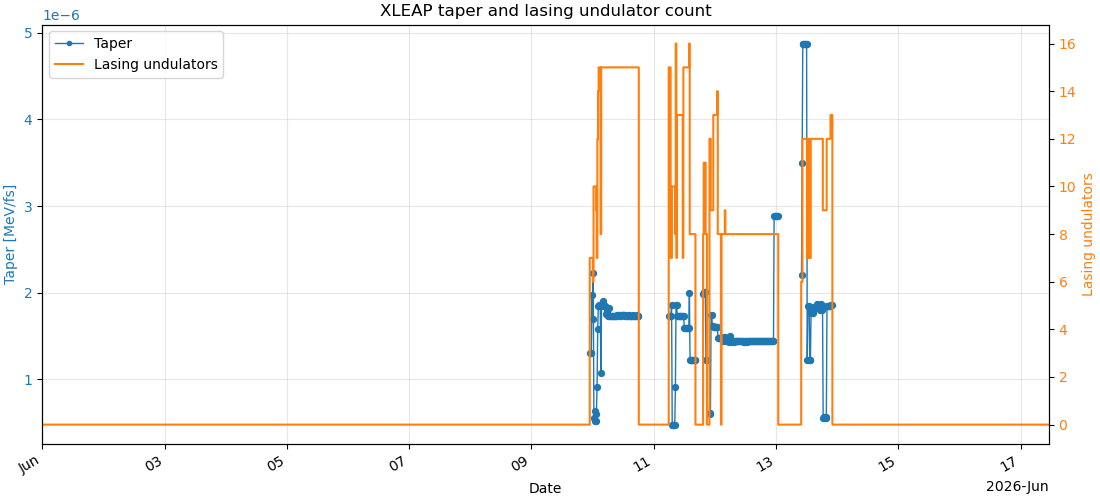

In [22]:
get_ipython().run_line_magic('matplotlib', 'widget')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

xleap_data = get_xleap_data(start, end)
xleap_df = pd.DataFrame(xleap_data).set_index('datetime').sort_index()

fig, taper_ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
und_ax = taper_ax.twinx()

xleap_mask = xleap_df['xleap_on']
taper_ax.plot(
    xleap_df.index,
    xleap_df['taper'],
    marker='o',
    markersize=3,
    linewidth=1,
    color='tab:blue',
    label='Taper',
)
und_ax.step(
    xleap_df.index,
    xleap_df['n_und'],
    where='mid',
    linewidth=1.5,
    color='tab:orange',
    label='Lasing undulators',
)

if xleap_mask.any():
    taper_ax.scatter(
        xleap_df.index[xleap_mask],
        xleap_df.loc[xleap_mask, 'taper'],
        s=18,
        color='tab:blue',
        zorder=3,
    )

taper_ax.set_xlim(xleap_df.index.min(), xleap_df.index.max())

taper_ax.set_title('XLEAP taper and lasing undulator count')
taper_ax.set_xlabel('Date')
taper_ax.set_ylabel('Taper [MeV/fs]', color='tab:blue')
und_ax.set_ylabel('Lasing undulators', color='tab:orange')
taper_ax.tick_params(axis='y', labelcolor='tab:blue')
und_ax.tick_params(axis='y', labelcolor='tab:orange')
taper_ax.grid(True, alpha=0.3)

locator = mdates.AutoDateLocator()
taper_ax.xaxis.set_major_locator(locator)
taper_ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

lines = taper_ax.get_lines() + und_ax.get_lines()
labels = [line.get_label() for line in lines]
taper_ax.legend(lines, labels, loc='upper left')

fig.autofmt_xdate()
plt.show()
